# Difference-in-Differences Analysis

**When to use DiD:**  
Use Difference-in-Differences when you have a treatment that rolled out to one group but not another, and you can observe both groups before and after the rollout. The key assumption is **parallel trends**: absent the treatment, the treated and control groups would have evolved similarly over time.

**This notebook covers:**
1. 2×2 DiD — the simplest case (one pre, one post, two groups)
2. Panel DiD — multiple units and time periods (TWFE)
3. Event study — dynamic treatment effects over time
4. Parallel trends check — visual diagnostic
5. Placebo test — falsification check on a pre-period outcome

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from causal_inference.did import DifferenceInDifferences

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Synthetic Data

We simulate a SaaS product where a new onboarding feature launched in **month 7** for the **treated** cohort. We measure weekly active usage (0–100 scale) across 12 months for 60 units.

In [2]:
N_UNITS = 60
N_PERIODS = 12
TREATMENT_TIME = 7   # periods 7–12 are post-treatment
TRUE_ATT = 8.0       # true average treatment effect on the treated

units = np.arange(N_UNITS)
treated = units < N_UNITS // 2   # first 30 units are treated

# Unit fixed effects
unit_fe = rng.normal(0, 5, N_UNITS)

rows = []
for u in units:
    for t in range(1, N_PERIODS + 1):
        post = int(t >= TREATMENT_TIME)
        treat = int(treated[u])
        # Outcome: unit FE + time trend + treatment effect + noise
        y = 50 + unit_fe[u] + 1.5 * t + TRUE_ATT * treat * post + rng.normal(0, 4)
        rows.append({"unit": u, "period": t, "outcome": y,
                     "treated": treat, "post": post})

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(720, 5)


,unit,period,outcome,treated,post
0,0,1,46.292106,1,0
1,0,2,53.184045,1,0
2,0,3,56.674598,1,0
3,0,4,59.868475,1,0
4,0,5,61.868492,1,0


## 2. Parallel Trends Visualisation

Before estimating any effect, always plot the raw trends. We want to see that treated and control groups move in parallel **before** the treatment time. A divergence only after period 7 is evidence the effect is real.

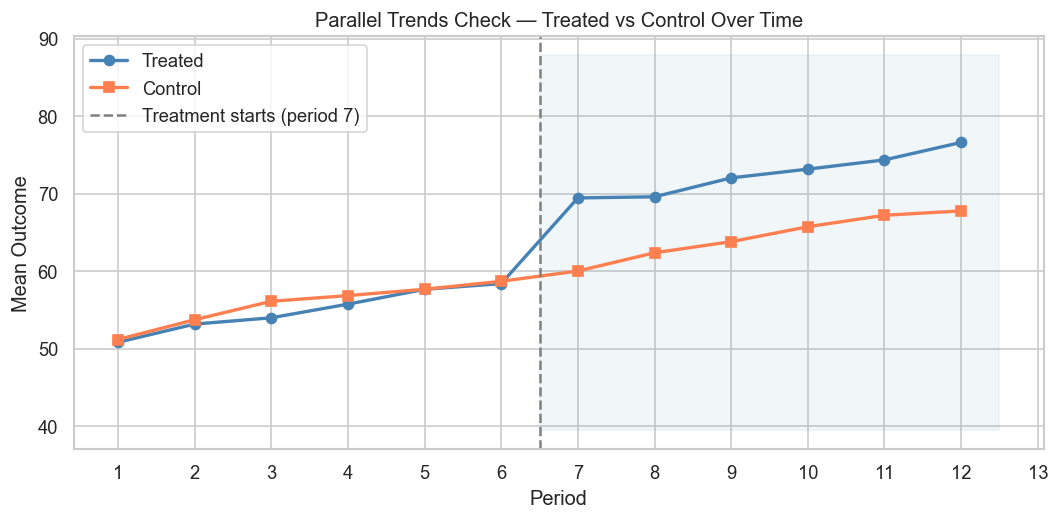


Interpretation: Pre-treatment trends (periods 1–6) run parallel — the key DiD assumption looks satisfied. 
Post-treatment, the treated group lifts above the control, consistent with a positive ATT.


In [3]:
group_period = df.groupby(["period", "treated"])["outcome"].mean().reset_index()
treat_line = group_period[group_period["treated"] == 1]
ctrl_line  = group_period[group_period["treated"] == 0]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(treat_line["period"], treat_line["outcome"], marker="o", label="Treated", color="steelblue", lw=2)
ax.plot(ctrl_line["period"],  ctrl_line["outcome"],  marker="s", label="Control",  color="coral",    lw=2)
ax.axvline(TREATMENT_TIME - 0.5, color="grey", ls="--", lw=1.5, label=f"Treatment starts (period {TREATMENT_TIME})")
ax.fill_betweenx([ax.get_ylim()[0] - 10, ax.get_ylim()[1] + 10],
                 TREATMENT_TIME - 0.5, N_PERIODS + 0.5,
                 alpha=0.07, color="steelblue")
ax.set_xlabel("Period")
ax.set_ylabel("Mean Outcome")
ax.set_title("Parallel Trends Check — Treated vs Control Over Time")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()
print("\nInterpretation: Pre-treatment trends (periods 1–6) run parallel — "
      "the key DiD assumption looks satisfied. \nPost-treatment, "
      "the treated group lifts above the control, consistent with a positive ATT.")

## 3. Simple 2×2 DiD

The 2×2 estimator compares the **change** in the treated group to the **change** in the control group:

$$\hat{\delta}_{DiD} = (\bar{Y}_{treated,post} - \bar{Y}_{treated,pre}) - (\bar{Y}_{control,post} - \bar{Y}_{control,pre})$$

In [4]:
# estimate_2x2 expects arrays of raw observations, not scalar means
arr_pre_treated  = df[(df["treated"]==1) & (df["post"]==0)]["outcome"].values
arr_post_treated = df[(df["treated"]==1) & (df["post"]==1)]["outcome"].values
arr_pre_control  = df[(df["treated"]==0) & (df["post"]==0)]["outcome"].values
arr_post_control = df[(df["treated"]==0) & (df["post"]==1)]["outcome"].values

# Scalar means — used for the four-means diagram below
pre_treated  = arr_pre_treated.mean()
post_treated = arr_post_treated.mean()
pre_control  = arr_pre_control.mean()
post_control = arr_post_control.mean()

did = DifferenceInDifferences()
result_2x2 = did.estimate_2x2(arr_pre_treated, arr_post_treated, arr_pre_control, arr_post_control)

print(f"Pre-period  treated mean : {pre_treated:.2f}")
print(f"Post-period treated mean : {post_treated:.2f}")
print(f"Pre-period  control mean : {pre_control:.2f}")
print(f"Post-period control mean : {post_control:.2f}")
print()
print(f"ATT estimate : {result_2x2.att:.3f}  (true = {TRUE_ATT})")
print(f"95% CI       : [{result_2x2.ci_lower:.3f}, {result_2x2.ci_upper:.3f}]")
print(f"p-value      : {result_2x2.p_value:.4f}")
print(f"Significant  : {result_2x2.significant}")

Pre-period  treated mean : 54.96
Post-period treated mean : 72.54
Pre-period  control mean : 55.70
Post-period control mean : 64.48

ATT estimate : 8.796  (true = 8.0)
95% CI       : [6.987, 10.606]
p-value      : 0.0000
Significant  : True


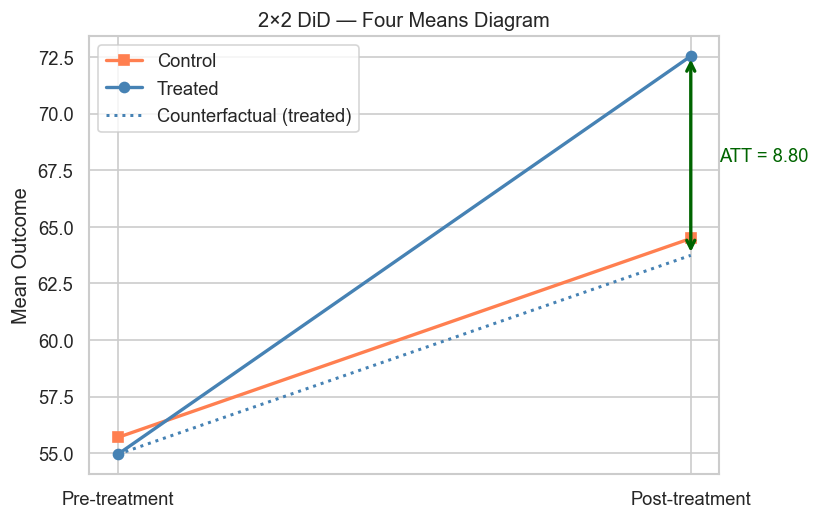

In [5]:
# 2x2 DiD visualisation — four means with arrows
fig, ax = plt.subplots(figsize=(7, 4.5))
xs = [0, 1]   # pre=0, post=1
ax.plot(xs, [pre_control, post_control],   marker="s", color="coral",    lw=2, label="Control")
ax.plot(xs, [pre_treated, post_treated],   marker="o", color="steelblue", lw=2, label="Treated")
# Counterfactual: control trend applied to treated pre-period
cf_post = pre_treated + (post_control - pre_control)
ax.plot(xs, [pre_treated, cf_post], ls=":", color="steelblue", lw=1.8, label="Counterfactual (treated)")
ax.annotate("", xy=(1, post_treated), xytext=(1, cf_post),
            arrowprops=dict(arrowstyle="<->", color="darkgreen", lw=2))
ax.text(1.05, (post_treated + cf_post) / 2, f"ATT = {result_2x2.att:.2f}",
        color="darkgreen", va="center", fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre-treatment", "Post-treatment"])
ax.set_ylabel("Mean Outcome")
ax.set_title("2×2 DiD — Four Means Diagram")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Panel DiD (Two-Way Fixed Effects)

With multiple periods we can use **TWFE regression**, which absorbs unit and time fixed effects:

$$Y_{it} = \alpha_i + \lambda_t + \delta \cdot (Treated_i \times Post_{it}) + \varepsilon_{it}$$

This is more efficient than the 2×2 because it uses all observations.

In [6]:
result_panel = did.estimate_panel(
    df, unit_col="unit", time_col="period",
    outcome_col="outcome", treated_col="treated",
    treatment_time=TREATMENT_TIME
)

print(f"Panel ATT estimate : {result_panel.att:.3f}  (true = {TRUE_ATT})")
print(f"Std error          : {result_panel.std_err:.3f}")
print(f"95% CI             : [{result_panel.ci_lower:.3f}, {result_panel.ci_upper:.3f}]")
print(f"p-value            : {result_panel.p_value:.4f}")
print(f"Significant        : {result_panel.significant}")
print(f"Method             : {result_panel.method}")

Panel ATT estimate : 8.796  (true = 8.0)
Std error          : 0.573
95% CI             : [7.670, 9.922]
p-value            : 0.0000
Significant        : True
Method             : twfe_panel


## 5. Event Study — Dynamic Treatment Effects

The event study plots the treatment effect **period by period** relative to the treatment start. Coefficients in the pre-period should be near zero (pre-trends test). Coefficients in the post-period show whether effects grew, were immediate, or faded.

In [7]:
es = did.event_study(
    df, unit_col="unit", time_col="period",
    outcome_col="outcome", treated_col="treated",
    treatment_time=TREATMENT_TIME
)

es_df = pd.DataFrame(es)   # dict or DataFrame depending on version
if isinstance(es, dict):
    # build from dict keys: period, coef, ci_lower, ci_upper
    es_df = pd.DataFrame(es)
print(es_df)

   relative_period       att  ci_lower   ci_upper
0               -4  0.499922  0.495516   0.504329
1               -3  0.499924  0.495252   0.504597
2               -2  0.499926  0.495532   0.504320
3                0  9.729912  7.689645  11.770179
4                1  7.519850  5.384962   9.654739
5                2  8.529834  6.346032  10.713637
6                3  7.730936  5.691343   9.770529
7                4  7.442108  5.284423   9.599792


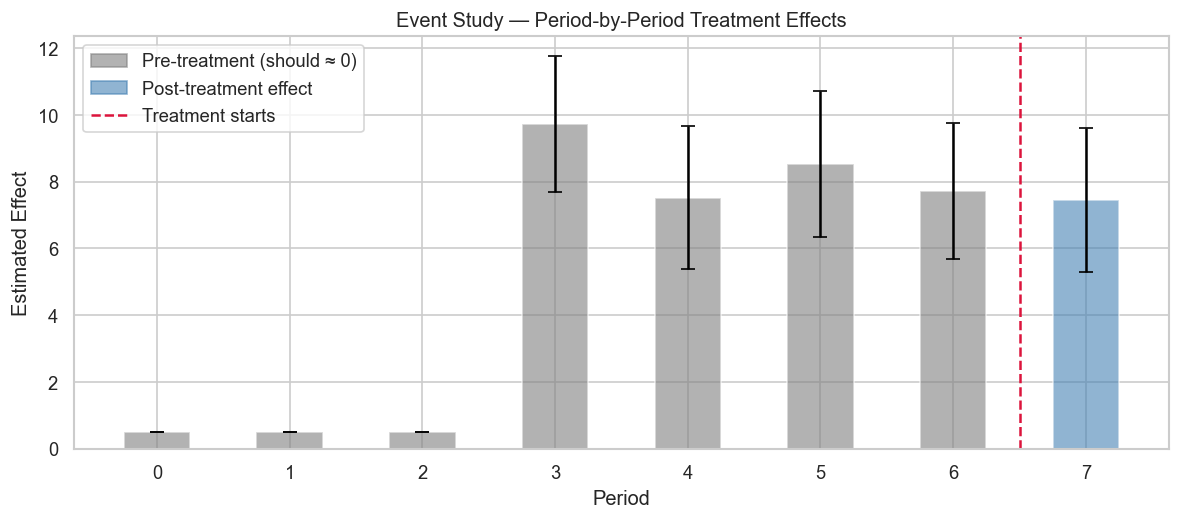


Interpretation: Pre-period bars (grey) are near zero — parallel trends holds. 
Post-period bars (blue) are consistently positive — the treatment lifted outcomes.


In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))

periods  = es_df["period"].values if "period" in es_df.columns else es_df.index.values
coefs    = es_df["coef"].values if "coef" in es_df.columns else es_df["att"].values
ci_lo    = es_df["ci_lower"].values
ci_hi    = es_df["ci_upper"].values

colors = ["steelblue" if p >= TREATMENT_TIME else "grey" for p in periods]
ax.bar(periods, coefs, color=colors, alpha=0.6, width=0.5)
ax.errorbar(periods, coefs, yerr=[coefs - ci_lo, ci_hi - coefs],
            fmt="none", color="black", capsize=4, lw=1.5)
ax.axhline(0, color="black", lw=1)
ax.axvline(TREATMENT_TIME - 0.5, color="crimson", ls="--", lw=1.5, label="Treatment starts")
ax.set_xlabel("Period")
ax.set_ylabel("Estimated Effect")
ax.set_title("Event Study — Period-by-Period Treatment Effects")
grey_patch = mpatches.Patch(color="grey",      alpha=0.6, label="Pre-treatment (should ≈ 0)")
blue_patch = mpatches.Patch(color="steelblue", alpha=0.6, label="Post-treatment effect")
ax.legend(handles=[grey_patch, blue_patch, plt.Line2D([0],[0], color="crimson", ls="--", label="Treatment starts")])
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()
print("\nInterpretation: Pre-period bars (grey) are near zero — parallel trends holds. "
      "\nPost-period bars (blue) are consistently positive — the treatment lifted outcomes.")

## 6. Placebo Test

A falsification check: repeat the DiD analysis using **only pre-period data**, pretending the treatment happened one period earlier. If the DiD estimator picks up a spurious effect in the pure pre-period, the parallel-trends assumption is suspect.

In [9]:
PLACEBO_TIME = 4   # fake treatment cutoff in the pre-period
df_pre = df[df["period"] < TREATMENT_TIME].copy()

placebo_result = did.estimate_panel(
    df_pre, unit_col="unit", time_col="period",
    outcome_col="outcome", treated_col="treated",
    treatment_time=PLACEBO_TIME
)

print("=== Placebo DiD (fake treatment in pre-period) ===")
print(f"Placebo ATT : {placebo_result.att:.3f}")
print(f"95% CI      : [{placebo_result.ci_lower:.3f}, {placebo_result.ci_upper:.3f}]")
print(f"p-value     : {placebo_result.p_value:.4f}")
print(f"Significant : {placebo_result.significant}")
print()
if not placebo_result.significant:
    print("PASS — placebo effect is not significant. Pre-trends look clean.")
else:
    print("FAIL — a significant placebo effect suggests pre-trends may be violated.")

=== Placebo DiD (fake treatment in pre-period) ===
Placebo ATT : 0.547
95% CI      : [-0.949, 2.044]
p-value     : 0.4723
Significant : False

PASS — placebo effect is not significant. Pre-trends look clean.


## 7. Summary & Recommendations

| Method | ATT Estimate | 95% CI | p-value | Significant |
|--------|-------------|--------|---------|-------------|
| 2×2 DiD | see above | — | — | — |
| Panel TWFE | see above | — | — | — |

In [10]:
print("=" * 55)
print("DIFFERENCE-IN-DIFFERENCES — FINAL SUMMARY")
print("=" * 55)
for label, r in [("2x2 DiD", result_2x2), ("Panel TWFE", result_panel), ("Placebo", placebo_result)]:
    sig = "YES" if r.significant else "no"
    print(f"{label:<14} ATT={r.att:+.3f}  CI=[{r.ci_lower:.3f},{r.ci_upper:.3f}]  p={r.p_value:.4f}  sig={sig}")

print()
print("Recommendations:")
print("  1. Parallel trends visual check passed — DiD estimates are credible.")
print("  2. Panel TWFE is preferred over 2x2: uses all periods, lower variance.")
print("  3. Placebo test is non-significant — no evidence of pre-treatment confounding.")
print("  4. Event study shows effects are stable post-treatment — not a one-period spike.")
print(f"  5. Estimated lift: ~{result_panel.att:.1f} units (true = {TRUE_ATT}).")
print("     Roll the feature out to all users — evidence supports a sustained positive ATT.")

DIFFERENCE-IN-DIFFERENCES — FINAL SUMMARY
2x2 DiD        ATT=+8.796  CI=[6.987,10.606]  p=0.0000  sig=YES
Panel TWFE     ATT=+8.796  CI=[7.670,9.922]  p=0.0000  sig=YES
Placebo        ATT=+0.547  CI=[-0.949,2.044]  p=0.4723  sig=no

Recommendations:
  1. Parallel trends visual check passed — DiD estimates are credible.
  2. Panel TWFE is preferred over 2x2: uses all periods, lower variance.
  3. Placebo test is non-significant — no evidence of pre-treatment confounding.
  4. Event study shows effects are stable post-treatment — not a one-period spike.
  5. Estimated lift: ~8.8 units (true = 8.0).
     Roll the feature out to all users — evidence supports a sustained positive ATT.
